# ClaimWise Insurance Prediction — 06. Random Forest Regressor

## 1. Objective

Train and evaluate a **Random Forest Regressor** model that predicts the insurance claim loss `loss`
from the 130 preprocessed input features.

Everything is loaded from the project's existing prepared data and helpers:

| Item | Location |
|---|---|
| Training / testing data | `Dataset/06_split_X_train.csv`, `06_split_X_test.csv`, `06_split_y_train.csv`, `06_split_y_test.csv` |
| Model definition | `Src/random_forest_regressor_model.py` → `build_model()` |
| Shared helpers | `Src/model_training_utils.py` (data loading, metrics, saving) |

A Random Forest builds many decision trees on random subsets of the data and features and
averages their predictions. Averaging reduces the overfitting of a single tree and usually gives a
strong, stable regressor. Feature importances are also available for interpretation.

## 2. Import Libraries

Standard plotting/data libraries, plus the project's own shared helpers
(`Src/model_training_utils.py`) and the module that defines this model.

In [1]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """Walk upwards from the notebook folder until the ClaimWise project is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "Dataset").is_dir() and (candidate / "Src").is_dir():
            return candidate
    raise FileNotFoundError(f"ClaimWise project root not found above: {start}")


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / "Dataset"
SRC_DIR = PROJECT_ROOT / "Src"
MODELS_DIR = PROJECT_ROOT / "Models"
OUTPUTS_DIR = PROJECT_ROOT / "Outputs"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root  :", PROJECT_ROOT)
print("Dataset folder:", DATASET_DIR)
print("Src folder    :", SRC_DIR)

from model_training_utils import (
    calculate_metrics,
    load_prepared_data,
    save_model_results,
)

Project root  : /Users/padaltiruvinayak/Desktop/Credit ML
Dataset folder: /Users/padaltiruvinayak/Desktop/Credit ML/Dataset
Src folder    : /Users/padaltiruvinayak/Desktop/Credit ML/Src


In [3]:
# Src/model_training_utils.py switches matplotlib to the non-interactive Agg backend so the
# command-line scripts can run without a display. Switch back to the inline backend here so
# that every figure below is rendered inside this notebook.
%matplotlib inline

In [4]:
from random_forest_regressor_model import build_model

MODEL_NAME = "Random Forest Regressor"
MODEL_FILE = "random_forest_regressor.pkl"
OUTPUT_FOLDER_NAME = "Random_Forest_Regressor"
MODEL_SLUG = "random_forest"

## 3. Load Dataset — Prepared Train/Test Data

The dataset is not re-preprocessed here: the project already provides the four prepared files
produced by `02_ClaimWise_Data_Preprocessing.ipynb`.

`load_prepared_data()` comes from the project helper module. It re-reads the four prepared files
and validates them (identical feature columns, one `loss` column in the targets, 130 numeric
features, no missing values) — so the data cannot be silently wrong.

In [5]:
X_train, X_test, y_train, y_test = load_prepared_data()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print("Target column :", y_train.name)
print("Input features:", X_train.shape[1])

X_train: (40000, 130) | X_test: (10000, 130)
y_train: (40000,) | y_test: (10000,)
Target column : loss
Input features: 130


## 4. Verify Train/Test Data

Explicit checks that the model input and target are correct before training starts.

In [6]:
verification = {
    "X_train rows == y_train rows": len(X_train) == len(y_train),
    "X_test rows == y_test rows": len(X_test) == len(y_test),
    "X_train and X_test share the same columns": list(X_train.columns) == list(X_test.columns),
    "target 'loss' is not a feature": "loss" not in X_train.columns,
    "all features are numeric": all(
        pd.api.types.is_numeric_dtype(dtype) for dtype in X_train.dtypes
    ),
    "no missing values in the features": not (
        X_train.isna().any().any() or X_test.isna().any().any()
    ),
    "no missing values in the target": not (y_train.isna().any() or y_test.isna().any()),
}
report = pd.DataFrame(
    [{"check": name, "result": "PASS" if ok else "FAIL"} for name, ok in verification.items()]
)
display(report)

failed = [name for name, ok in verification.items() if not ok]
if failed:
    raise AssertionError(f"Train/test verification failed: {failed}")
print("All", len(verification), "checks passed.")

,check,result
0,X_train rows == y_train rows,PASS
1,X_test rows == y_test rows,PASS
2,X_train and X_test share the same columns,PASS
3,target 'loss' is not a feature,PASS
4,all features are numeric,PASS
5,no missing values in the features,PASS
6,no missing values in the target,PASS


All 7 checks passed.


## 5. Create the Model

The model object comes from `Src/{src_module}.py`, so the hyperparameters used here are identical
to the ones used by the command-line training scripts.

In [7]:
model = build_model()
model_params = pd.Series(model.get_params(), name="value").to_frame()
print(type(model).__name__)
display(model_params)

RandomForestRegressor


,value
bootstrap,True
ccp_alpha,0.0
criterion,squared_error
max_depth,20
max_features,1.0
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,2
min_samples_split,2


## 6. Model Training

The model learns the relationship between the features and `loss` from the **training** data only.
The test data is never shown to the model during fitting.

In [8]:
start_time = time.time()
model.fit(X_train, y_train)
training_seconds = time.time() - start_time
print(f"{MODEL_NAME} fitted on {X_train.shape[0]} rows in {training_seconds:.2f} seconds")

Random Forest Regressor fitted on 40000 rows in 15.21 seconds


## 7. Prediction

Predictions are generated for the 10,000 unseen test rows.

In [9]:
y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    "Actual_Loss": y_test.to_numpy(),
    "Predicted_Loss": y_pred,
    "Residual": y_test.to_numpy() - y_pred,
})
print("First 10 predictions on the held-out test set:")
display(predictions.head(10))

First 10 predictions on the held-out test set:


,Actual_Loss,Predicted_Loss,Residual
0,3302.33,3930.164347,-627.834347
1,1021.53,2005.531429,-984.001429
2,580.00,4340.326337,-3760.326337
3,1109.79,1714.793322,-605.003322
4,4325.72,3900.164118,425.555882
5,5344.24,6595.922926,-1251.682926
6,1173.77,1779.012216,-605.242216
7,13018.78,11980.918159,1037.861841
8,709.01,1862.857809,-1153.847809
9,3759.36,4000.309888,-240.949888


## 8. Evaluation

Because `loss` is a continuous amount, this is a **regression** problem. The metrics are:

- **MAE** — average absolute error, in the same unit as `loss`
- **MSE** — mean squared error (penalises large errors)
- **RMSE** — square root of MSE, again in the unit of `loss`
- **R²** — how much of the variance of `loss` the model explains (1.0 = perfect)

Classification accuracy is never used here — it would be meaningless for a regression target.

In [10]:
metrics = calculate_metrics(y_test, y_pred)
metrics_frame = pd.DataFrame([{"Model": MODEL_NAME, **metrics}])
display(metrics_frame)

print(f"MAE  : {metrics['MAE']:.4f}   average absolute error of the predicted loss")
print(f"MSE  : {metrics['MSE']:.4f}   mean squared error")
print(f"RMSE : {metrics['RMSE']:.4f}   average error in the same unit as 'loss'")
print(f"R2   : {metrics['R2']:.6f}   variance of 'loss' explained by the model")

,Model,MAE,MSE,RMSE,R2
0,Random Forest Regressor,1259.621849,3.937887e+06,1984.410916,0.51544


MAE  : 1259.6218   average absolute error of the predicted loss
MSE  : 3937886.6824   mean squared error
RMSE : 1984.4109   average error in the same unit as 'loss'
R2   : 0.515440   variance of 'loss' explained by the model


## 9. Visualization

Actual vs predicted loss and the residual plot, both computed from the real test predictions.

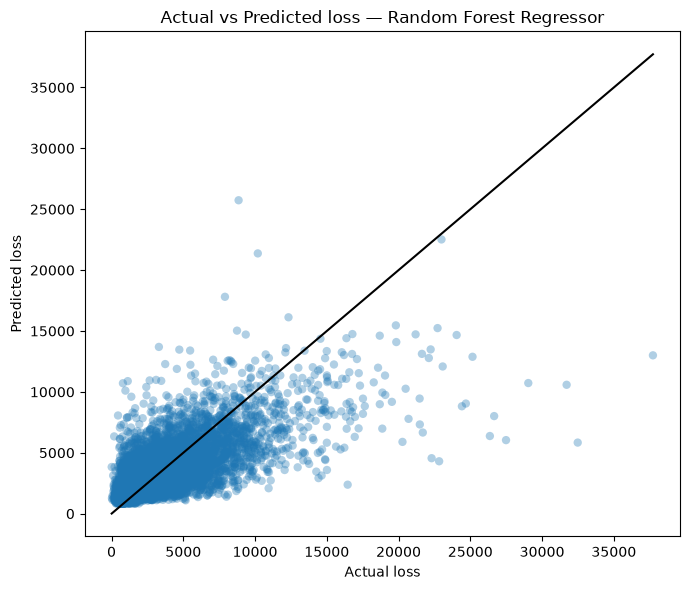

Saved: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Random_Forest_Regressor/random_forest_actual_vs_predicted.png


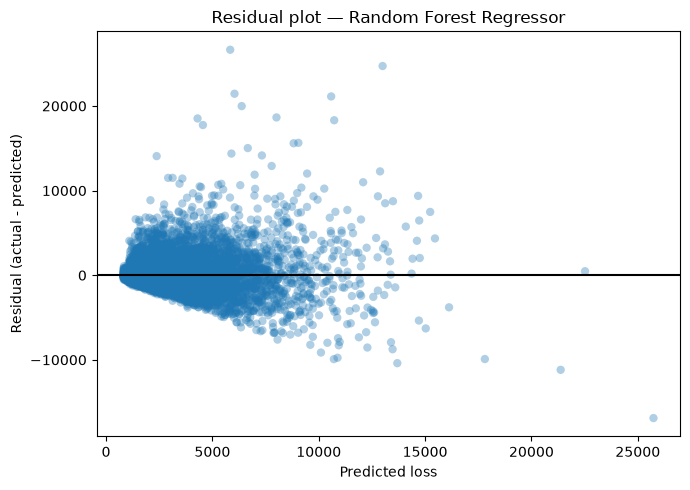

Saved: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Random_Forest_Regressor/random_forest_residuals.png


In [11]:
model_output_dir = OUTPUTS_DIR / OUTPUT_FOLDER_NAME
model_output_dir.mkdir(parents=True, exist_ok=True)

actual = y_test.to_numpy()
predicted = y_pred
residuals = actual - predicted

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(actual, predicted, alpha=0.35, edgecolors="none")
limit_min = float(min(actual.min(), predicted.min()))
limit_max = float(max(actual.max(), predicted.max()))
ax.plot([limit_min, limit_max], [limit_min, limit_max], color="black", linewidth=1.5)
ax.set_title(f"Actual vs Predicted loss — {MODEL_NAME}")
ax.set_xlabel("Actual loss")
ax.set_ylabel("Predicted loss")
fig.tight_layout()
fig.savefig(model_output_dir / f"{MODEL_SLUG}_actual_vs_predicted.png", dpi=150)
plt.show()
print("Saved:", model_output_dir / f"{MODEL_SLUG}_actual_vs_predicted.png")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(predicted, residuals, alpha=0.35, edgecolors="none")
ax.axhline(0, color="black", linewidth=1.5)
ax.set_title(f"Residual plot — {MODEL_NAME}")
ax.set_xlabel("Predicted loss")
ax.set_ylabel("Residual (actual - predicted)")
fig.tight_layout()
fig.savefig(model_output_dir / f"{MODEL_SLUG}_residuals.png", dpi=150)
plt.show()
print("Saved:", model_output_dir / f"{MODEL_SLUG}_residuals.png")

## 10. Feature Importance

Top 10 features by Random Forest importance:


,Feature,Importance
0,cat80,0.253019
1,cont7,0.115487
2,cat57,0.051132
3,cont2,0.049582
4,cat79,0.042155
5,cont14,0.036927
6,cat101,0.029373
7,cat12,0.024975
8,cat81,0.021443
9,cont3,0.016051


Saved: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Random_Forest_Regressor/feature_importance.csv
Saved: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Random_Forest_Regressor/feature_importance.png
Random Forest feature-importance chart:


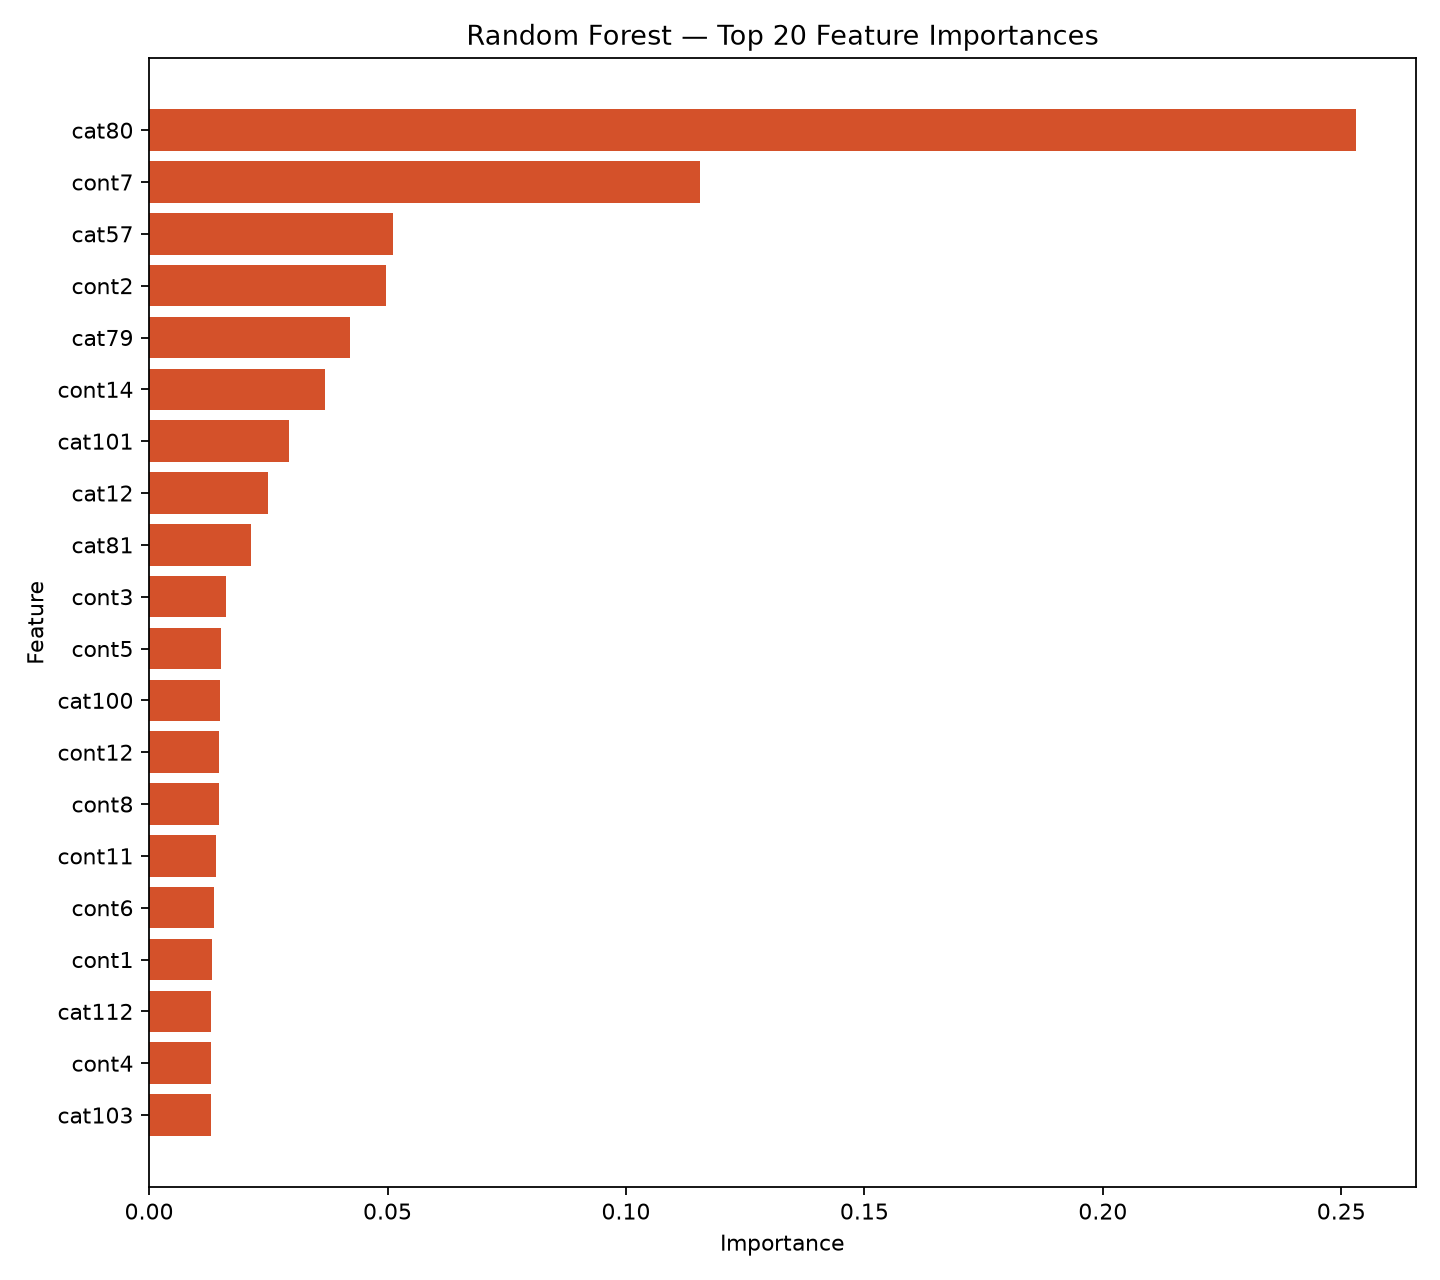

In [12]:
model_output_dir = OUTPUTS_DIR / OUTPUT_FOLDER_NAME
model_output_dir.mkdir(parents=True, exist_ok=True)

from model_training_utils import save_random_forest_feature_importance

# Saves Outputs/Random_Forest_Regressor/feature_importance.csv and feature_importance.png
save_random_forest_feature_importance(model, X_train.columns)

importance = pd.read_csv(model_output_dir / "feature_importance.csv")
print("Top 10 features by Random Forest importance:")
display(importance.head(10))
print("Saved:", model_output_dir / "feature_importance.csv")
print("Saved:", model_output_dir / "feature_importance.png")

from IPython.display import Image

print("Random Forest feature-importance chart:")
display(Image(filename=str(model_output_dir / "feature_importance.png")))

## 11. Save Results

The trained model, its metrics and its per-row predictions are written to the project folders:

- `Models/{model_file}`
- `Outputs/{folder}/metrics.csv`
- `Outputs/{folder}/predictions.csv`

In [13]:
saved_metrics = save_model_results(
    MODEL_NAME, MODEL_FILE, model, X_test, y_test, y_pred
)

print("Saved model      :", MODELS_DIR / MODEL_FILE)
print("Saved metrics    :", OUTPUTS_DIR / OUTPUT_FOLDER_NAME / "metrics.csv")
print("Saved predictions:", OUTPUTS_DIR / OUTPUT_FOLDER_NAME / "predictions.csv")
display(pd.DataFrame([{"Model": MODEL_NAME, **saved_metrics}]))

Saved model      : /Users/padaltiruvinayak/Desktop/Credit ML/Models/random_forest_regressor.pkl
Saved metrics    : /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Random_Forest_Regressor/metrics.csv
Saved predictions: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Random_Forest_Regressor/predictions.csv


,Model,MAE,MSE,RMSE,R2
0,Random Forest Regressor,1259.621849,3.937887e+06,1984.410916,0.51544


## 12. Conclusion

Random Forest Regressor was trained on the 40,000 prepared training rows and evaluated on the 10,000
held-out test rows. Actual results of this run:

| Model | MAE | MSE | RMSE | R² |
|---|---:|---:|---:|---:|
| Random Forest Regressor | 1259.6218 | 3937886.6824 | 1984.4109 | 0.515440 |

This is the second-lowest RMSE and the second-highest R² of the five models in this run — the histogram gradient boosting model added in notebook 08 beats it slightly on both. Most important features: `cat80` (0.2530), `cont7` (0.1155) and `cat57` (0.0511). Artifacts: `Models/random_forest_regressor.pkl`, `Outputs/Random_Forest_Regressor/metrics.csv`, `predictions.csv` and `feature_importance.csv/png`.

The model comparison across all five algorithms is done in
`09_ClaimWise_Model_Comparison.ipynb`.